# 三花智控近一年交易数据获取与绘图

本 notebook 演示使用 Ricequant RQData 获取三花智控 `002050.XSHE` 近一年日线行情，并在本地保存数据，同时绘制 K 线图和成交量图。

- 数据源：Ricequant RQData `rqdatac.get_price`
- 频率：日线 `1d`
- 字段：`open`、`high`、`low`、`close`、`volume`、`total_turnover`
- 复权：前复权 `adjust_type="pre"`

## 1. 导入依赖并设置路径

请在 `quant` conda 环境中运行本 notebook。数据会保存到项目的 `data/` 目录。

In [1]:
from __future__ import annotations

import json
from datetime import date, datetime, timedelta
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import rqdatac
from matplotlib.patches import Rectangle

plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS",
    "PingFang SC",
    "Heiti TC",
    "SimHei",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
REPORT_DIR = ROOT / "reports"
DATA_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

ORDER_BOOK_ID = "002050.XSHE"
SYMBOL_NAME = "三花智控"

CSV_PATH = DATA_DIR / "sanhua_002050_xshe_daily_last_year.csv"
JSON_PATH = DATA_DIR / "sanhua_002050_xshe_daily_last_year.json"
HTML_PATH = REPORT_DIR / "sanhua_002050_xshe_panel.html"

ORDER_BOOK_ID, CSV_PATH, JSON_PATH, HTML_PATH

('002050.XSHE',
 PosixPath('/Users/dawn/quant/Quant/BA 量化/data/sanhua_002050_xshe_daily_last_year.csv'),
 PosixPath('/Users/dawn/quant/Quant/BA 量化/data/sanhua_002050_xshe_daily_last_year.json'),
 PosixPath('/Users/dawn/quant/Quant/BA 量化/reports/sanhua_002050_xshe_panel.html'))

## 2. 初始化 RQData 并确认证券信息

`rqdatac.init()` 会读取本机已配置好的 Ricequant SDK / RQData 认证信息。

In [2]:
rqdatac.init()

instrument = rqdatac.instruments(ORDER_BOOK_ID)
instrument

Instrument(order_book_id='002050.XSHE', industry_code='C34', market_tplus=1, symbol='三花智控', special_type='Normal', exchange='XSHE', status='Active', type='CS', de_listed_date='0000-00-00', listed_date='2005-06-07', sector_code_name='工业', abbrev_symbol='SHZK', sector_code='Industrials', round_lot=100, trading_hours='09:31-11:30,13:01-15:00', board_type='MainBoard', industry_name='通用设备制造业', issue_price=7.39, trading_code='002050', office_address='浙江省绍兴市新昌县澄潭街道沃西大道219号三花工业园区办公大楼', province='浙江省', citics_industry_code='33', citics_industry_name='家电')

## 3. 计算近一年交易日窗口

先找最近一个交易日，再从其一年前开始对齐到交易日，避免周末或节假日导致结束日期没有行情。

In [3]:
def date_text(value) -> str:
    if hasattr(value, "strftime"):
        return value.strftime("%Y-%m-%d")
    return str(value)


def get_date_window() -> tuple[str, str]:
    today = date.today()
    recent_dates = rqdatac.get_trading_dates(today - timedelta(days=21), today)
    if not recent_dates:
        raise RuntimeError("未能获取最近交易日，请检查 RQData 权限或网络。")

    end_date = recent_dates[-1]
    raw_start = end_date - pd.DateOffset(years=1)
    trading_dates = rqdatac.get_trading_dates(raw_start.date(), end_date)
    if not trading_dates:
        raise RuntimeError("未能获取近一年交易日，请检查 RQData 权限或网络。")

    return date_text(trading_dates[0]), date_text(end_date)


START_DATE, END_DATE = get_date_window()
START_DATE, END_DATE

('2025-07-03', '2026-07-03')

## 4. 获取日线价格和成交量

调用 `rqdatac.get_price` 获取开高低收、成交量和成交额，并整理出涨跌额、涨跌幅等分析字段。

In [4]:
def fetch_price_data(start_date: str, end_date: str) -> pd.DataFrame:
    fields = ["open", "high", "low", "close", "volume", "total_turnover"]
    data = rqdatac.get_price(
        ORDER_BOOK_ID,
        start_date=start_date,
        end_date=end_date,
        frequency="1d",
        fields=fields,
        adjust_type="pre",
        skip_suspended=False,
        expect_df=True,
    )
    if data is None or data.empty:
        raise RuntimeError(f"{ORDER_BOOK_ID} 在 {start_date} 至 {end_date} 无行情数据。")

    df = data.reset_index()
    if "date" not in df.columns:
        first_col = df.columns[0]
        df = df.rename(columns={first_col: "date"})

    df["date"] = pd.to_datetime(df["date"]).dt.strftime("%Y-%m-%d")
    if "order_book_id" not in df.columns:
        df.insert(1, "order_book_id", ORDER_BOOK_ID)
    df["order_book_id"] = ORDER_BOOK_ID
    if "symbol" not in df.columns:
        df.insert(2, "symbol", SYMBOL_NAME)
    df["symbol"] = SYMBOL_NAME

    numeric_cols = ["open", "high", "low", "close", "volume", "total_turnover"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["price_change"] = df["close"].diff()
    df["pct_change"] = df["close"].pct_change() * 100
    df["volume_shares"] = df["volume"]
    df["amount_yuan"] = df["total_turnover"]

    return df[
        [
            "date",
            "order_book_id",
            "symbol",
            "open",
            "high",
            "low",
            "close",
            "price_change",
            "pct_change",
            "volume_shares",
            "amount_yuan",
            "volume",
            "total_turnover",
        ]
    ]


df = fetch_price_data(START_DATE, END_DATE)
df.head()

,date,order_book_id,symbol,open,high,low,close,price_change,pct_change,volume_shares,amount_yuan,volume,total_turnover
0,2025-07-03,002050.XSHE,三花智控,25.653828,26.052954,25.653828,25.903281,NaN,NaN,35592079.0,9.215481e+08,35592079.0,9.215481e+08
1,2025-07-04,002050.XSHE,三花智控,25.813478,25.933216,25.464243,25.613915,-0.289366,-1.117103,46602659.0,1.198997e+09,46602659.0,1.198997e+09
2,2025-07-07,002050.XSHE,三花智控,25.464243,25.464243,25.055138,25.115007,-0.498908,-1.947799,47653176.0,1.201288e+09,47653176.0,1.201288e+09
3,2025-07-08,002050.XSHE,三花智控,25.115007,25.454264,25.005248,25.414352,0.299345,1.191895,36539759.0,9.279550e+08,36539759.0,9.279550e+08
4,2025-07-09,002050.XSHE,三花智控,25.514133,25.843412,25.394396,25.414352,0.000000,0.000000,44247692.0,1.133849e+09,44247692.0,1.133849e+09


In [5]:
df.tail()

,date,order_book_id,symbol,open,high,low,close,price_change,pct_change,volume_shares,amount_yuan,volume,total_turnover
238,2026-06-29,002050.XSHE,三花智控,41.48,42.10,40.35,41.27,-0.23,-0.554217,91201833.0,3.754259e+09,91201833.0,3.754259e+09
239,2026-06-30,002050.XSHE,三花智控,42.01,44.29,41.69,43.83,2.56,6.203053,130464531.0,5.630490e+09,130464531.0,5.630490e+09
240,2026-07-01,002050.XSHE,三花智控,43.83,45.40,43.33,44.21,0.38,0.866986,125367772.0,5.570153e+09,125367772.0,5.570153e+09
241,2026-07-02,002050.XSHE,三花智控,44.78,46.50,43.88,44.92,0.71,1.605971,179986729.0,8.160538e+09,179986729.0,8.160538e+09
242,2026-07-03,002050.XSHE,三花智控,44.00,49.41,43.99,48.99,4.07,9.060552,321530078.0,1.537120e+10,321530078.0,1.537120e+10


## 5. 保存到本地

保存两份数据：

- CSV：适合 Excel、pandas 或其他分析工具读取
- JSON：包含元数据和逐日行情记录，适合前端面板或自动化流程读取

In [6]:
def frame_to_records(frame: pd.DataFrame) -> list[dict]:
    object_df = frame.astype(object).where(pd.notnull(frame), None)
    records = object_df.to_dict(orient="records")
    for record in records:
        for key, value in list(record.items()):
            if hasattr(value, "item"):
                record[key] = value.item()
    return records


metadata = {
    "symbol": SYMBOL_NAME,
    "order_book_id": ORDER_BOOK_ID,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "frequency": "1d",
    "adjust_type": "pre",
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "source": "Ricequant RQData rqdatac.get_price",
    "record_count": int(len(df)),
}

df.to_csv(CSV_PATH, index=False, encoding="utf-8-sig")
JSON_PATH.write_text(
    json.dumps({"metadata": metadata, "data": frame_to_records(df)}, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

metadata, CSV_PATH, JSON_PATH

({'symbol': '三花智控',
  'order_book_id': '002050.XSHE',
  'start_date': '2025-07-03',
  'end_date': '2026-07-03',
  'frequency': '1d',
  'adjust_type': 'pre',
  'generated_at': '2026-07-04T22:57:51',
  'source': 'Ricequant RQData rqdatac.get_price',
  'record_count': 243},
 PosixPath('/Users/dawn/quant/Quant/BA 量化/data/sanhua_002050_xshe_daily_last_year.csv'),
 PosixPath('/Users/dawn/quant/Quant/BA 量化/data/sanhua_002050_xshe_daily_last_year.json'))

## 6. 快速统计

先查看区间收盘价、区间涨跌幅、最高价、最低价和日均成交量。

In [7]:
summary = pd.Series(
    {
        "开始日期": START_DATE,
        "结束日期": END_DATE,
        "交易日数量": len(df),
        "首日收盘价": df["close"].iloc[0],
        "最新收盘价": df["close"].iloc[-1],
        "区间涨跌幅%": (df["close"].iloc[-1] / df["close"].iloc[0] - 1) * 100,
        "区间最高价": df["high"].max(),
        "区间最低价": df["low"].min(),
        "日均成交量_股": df["volume_shares"].mean(),
        "日均成交额_元": df["amount_yuan"].mean(),
    }
)
summary

开始日期             2025-07-03
结束日期             2026-07-03
交易日数量                   243
首日收盘价             25.903281
最新收盘价                 48.99
区间涨跌幅%            89.126619
区间最高价                 60.77
区间最低价             25.005248
日均成交量_股      154207832.8107
日均成交额_元    7002442294.83358
dtype: object

## 7. 绘制 K 线图和成交量图

红色代表收盘价不低于开盘价，绿色代表收盘价低于开盘价；下方面板为成交量。

/var/folders/nl/vrwzfbpj6kn67d59nptx3_y40000gp/T/ipykernel_74126/3146501858.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


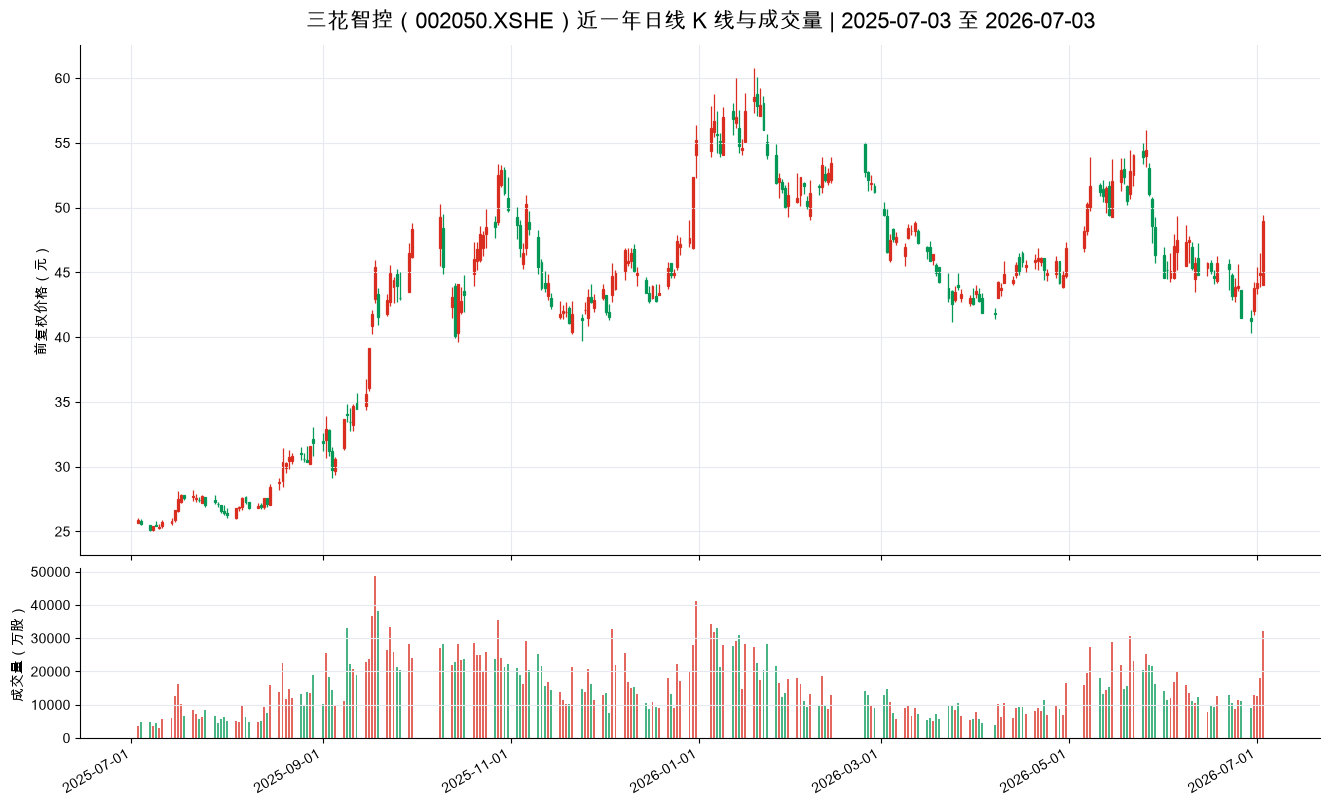

In [8]:
def plot_candlestick_with_volume(
    frame: pd.DataFrame,
    title: str,
) -> tuple[plt.Figure, tuple[plt.Axes, plt.Axes]]:
    plot_df = frame.copy()
    plot_df["date_dt"] = pd.to_datetime(plot_df["date"])
    plot_df["date_num"] = mdates.date2num(plot_df["date_dt"])

    fig, (ax_price, ax_volume) = plt.subplots(
        2,
        1,
        figsize=(16, 9),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.04},
    )

    candle_width = 0.62
    up_color = "#d92d20"
    down_color = "#039855"

    for row in plot_df.itertuples(index=False):
        color = up_color if row.close >= row.open else down_color
        x = row.date_num

        ax_price.vlines(x, row.low, row.high, color=color, linewidth=0.9)
        body_low = min(row.open, row.close)
        body_height = abs(row.close - row.open)
        if body_height == 0:
            body_height = 0.01
        rect = Rectangle(
            (x - candle_width / 2, body_low),
            candle_width,
            body_height,
            facecolor=color if row.close < row.open else "white",
            edgecolor=color,
            linewidth=0.9,
        )
        ax_price.add_patch(rect)

        ax_volume.bar(x, row.volume_shares / 10000, width=candle_width, color=color, alpha=0.72)

    ax_price.set_title(title, fontsize=16, pad=12)
    ax_price.set_ylabel("前复权价格（元）")
    ax_price.grid(True, color="#e6e9ef", linewidth=0.8)

    ax_volume.set_ylabel("成交量（万股）")
    ax_volume.grid(True, axis="y", color="#e6e9ef", linewidth=0.8)
    ax_volume.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=8, maxticks=12))
    ax_volume.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.setp(ax_volume.get_xticklabels(), rotation=30, ha="right")

    for ax in (ax_price, ax_volume):
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.tight_layout()
    return fig, (ax_price, ax_volume)


fig, axes = plot_candlestick_with_volume(
    df,
    f"{SYMBOL_NAME}（{ORDER_BOOK_ID}）近一年日线 K 线与成交量 | {START_DATE} 至 {END_DATE}",
)
plt.show()

## 8. 可选：复用项目脚本生成 HTML 面板

项目里已有 `scripts/fetch_sanhua_panel.py`，它会重新拉取数据并生成自包含 HTML 面板：`reports/sanhua_002050_xshe_panel.html`。

In [9]:
# 如果希望从 notebook 中同步刷新 HTML 面板，可以取消下面两行注释。
# import subprocess, sys
# subprocess.run([sys.executable, str(ROOT / "scripts" / "fetch_sanhua_panel.py")], check=True)

HTML_PATH

PosixPath('/Users/dawn/quant/Quant/BA 量化/reports/sanhua_002050_xshe_panel.html')